# RAGMAR Offline Analysis


In [15]:
from pathlib import Path
import json, re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (10, 4),
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})

# ============================================================================
RESULTS_DIR  = "results_new"
BASELINE_JOB = "124094"               # SLURM id of the reference arm; None = earliest job present
# ============================================================================

ROOT    = Path.cwd().parent if Path.cwd().name.lower() == "analysis" else Path.cwd()
RESULTS = ROOT / RESULTS_DIR
FIGS    = ROOT / "Analysis" / "figures" / RESULTS_DIR / "offline"
FIGS.mkdir(parents=True, exist_ok=True)

if not RESULTS.is_dir():
    raise SystemExit("RESULTS_DIR does not exist: " + str(RESULTS))

SKIP_DIRS = {"redundent", "old"}

STAGES       = ["read", "chunk", "embed", "index"]
STAGE_COLOR  = {"read": "#8C8C8C", "chunk": "#4C72B0", "embed": "#DD8452", "index": "#55A868"}
EMBED_DIM    = {"all-MiniLM-L6-v2": 384, "multi-qa-mpnet-base-dot-v1": 768}
EMBED_MAXTOK = {"all-MiniLM-L6-v2": 256, "multi-qa-mpnet-base-dot-v1": 512}
CHARS_PER_TOKEN = 4.0   # rough English-prose ratio for WordPiece/BPE; used only in section 5


def find(pattern):
    # Every file under results/ matching `pattern`, at whatever depth its artefact kind puts it, skipping SKIP_DIRS.
    seen = {}
    for p in sorted(RESULTS.rglob(pattern)):
        if SKIP_DIRS & set(p.relative_to(RESULTS).parts[:-1]):
            continue
        seen.setdefault(p.name, p)
    return [seen[k] for k in sorted(seen)]


print("data set:", RESULTS)
print("figures :", FIGS)
for kind, pat in [("configs ", "*_config.json"),
                  ("traces  ", "offline_*.json"),
                  ("hardware", "hardware_offline_*.csv"),
                  ("index   ", "*.index.faiss")]:
    hits = find(pat)
    where = sorted({str(p.parent.relative_to(RESULTS)) for p in hits}) or ["-"]
    print("{}: {:>2} file(s) in {}".format(kind, len(hits), ", ".join(where)))

skipped = sorted({p.name for d in SKIP_DIRS for p in RESULTS.rglob(d + "/*")})
print("\nexcluded by SKIP_DIRS:", ", ".join(skipped) or "nothing")

data set: e:\RAGNAR\results_new
figures : e:\RAGNAR\Analysis\figures\results_new\offline
configs :  3 file(s) in configs
traces  :  3 file(s) in offline
hardware:  3 file(s) in hardware
index   :  0 file(s) in -

excluded by SKIP_DIRS: nothing


## Load the build traces

One row per run in `runs`, one row per batch in `batches`. The arm label is not
hard-coded — it is computed by diffing each run's resolved config against the baseline's,
so adding a new arm to `configs/` and re-running the notebook labels itself.

In [16]:
def flatten(d, prefix=""):
    out = {}
    for k, v in d.items():
        key = prefix + k
        if isinstance(v, dict):
            out.update(flatten(v, key + "."))
        else:
            out[key] = v
    return out


OFFLINE_PREFIXES = ("chunker.", "embedder.", "index.", "offline.")


def load_configs():
    cfgs = {}
    for p in find("*_config.json"):
        d = json.loads(p.read_text(encoding="utf-8"))
        cfgs[str(d["job_id"])] = d
    return cfgs


CFG = load_configs()

# Resolve the reference arm against the data set that actually loaded, so a
# swapped-in results folder needs no second edit. An explicit BASELINE_JOB that
# is not present in the dump is a typo, not a fallback - say so.
if BASELINE_JOB is None:
    BASELINE_JOB = sorted(CFG)[0]
    print("BASELINE_JOB auto-selected (earliest job in dump):", BASELINE_JOB)
elif BASELINE_JOB not in CFG:
    raise SystemExit("BASELINE_JOB " + BASELINE_JOB + " has no config in " + str(RESULTS)
                     + "; present: " + ", ".join(sorted(CFG)))


def offline_flat(job):
    f = flatten(CFG[job]["resolved"])
    # index.chroma.* is carried by every config regardless of backend, so it would
    # otherwise show up as a spurious diff for the FAISS arms.
    return {k: v for k, v in f.items()
            if k.startswith(OFFLINE_PREFIXES) and not k.startswith("index.chroma.")}


def arm_change(job, base=BASELINE_JOB):
    if job == base:
        return "- (reference)"
    a, b = offline_flat(base), offline_flat(job)
    diff = {k: b[k] for k in b if a.get(k) != b[k]}
    if not diff:
        return "baseline replicate (no offline-path change)"
    return ", ".join(k + "=" + str(v) for k, v in sorted(diff.items()))


def load_runs():
    rows, brows = [], []
    for p in find("offline_*.json"):
        backend, job = re.match(r"offline_(\w+?)_(\d+)\.json", p.name).groups()
        d   = json.loads(p.read_text(encoding="utf-8"))
        cfg = CFG.get(job, {}).get("resolved", {})
        env = d.get("environment", {})
        wt  = d.get("wall_time", {})
        wu  = d.get("warmup", {}) or {}
        row = {
            "job_id": job,
            "backend": backend,
            "config": Path(CFG[job]["config_source"]).stem if job in CFG else "?",
            "change_vs_baseline": arm_change(job) if job in CFG else "?",
            "chunker":  cfg.get("chunker", {}).get("type"),
            "embedder": cfg.get("embedder", {}).get("model"),
            "metric":   cfg.get("embedder", {}).get("metric"),
            "database": cfg.get("index", {}).get("database"),
            "index_type": cfg.get("index", {}).get("type"),
            "n_passages": d["n_passages"],
            "n_chunks":   d["n_chunks"],
            "chunk_chars_avg": d["chunk_size_avg"],
            "chunk_chars_min": d["chunk_size_min"],
            "chunk_chars_max": d["chunk_size_max"],
            "total_ms":       d["latency_ms"]["total"],
            "unaccounted_ms": d["latency_ms"].get("unaccounted"),
            "embed_chunks_s": d["embed_throughput"]["chunks_per_sec"],
            "chunk_chunks_s": d["chunk_throughput"]["chunks_per_sec"],
            "build_start": pd.Timestamp(wt["build_start"]),
            "build_end":   pd.Timestamp(wt["build_end"]),
            "proc_start":     pd.Timestamp(env["process_started_at"]),
            "embedder_ready": pd.Timestamp(env["embedder_ready_at"]),
            "chunker_ready":  pd.Timestamp(env["chunker_ready_at"]),
            "db_ready":       pd.Timestamp(env["db_ready_at"]),
            "env_import_model_ms": env["latency_ms"]["import_and_model_load"],
            "env_chunker_ms":      env["latency_ms"]["chunker_build"],
            "env_db_ms":           env["latency_ms"]["db_import_and_build"],
            "env_total_ms":        env["latency_ms"]["total"],
            "warmup_start": pd.Timestamp(wu["started_at"]) if wu.get("started_at") else pd.NaT,
            "warmup_end":   pd.Timestamp(wu["ended_at"])   if wu.get("ended_at")   else pd.NaT,
            "warmup_ms":    wu.get("total_ms"),
        }
        row.update({s + "_ms": d["latency_ms"][s] for s in STAGES})
        rows.append(row)

        for b in d.get("batches", []):
            w = b["wall_time"]
            br = {
                "job_id": job, "batch_idx": b["batch_idx"],
                "is_training_batch": b.get("is_training_batch"),
                "n_passages": b["n_passages"], "n_chunks": b["n_chunks"],
                "n_skipped": b.get("n_skipped"), "skip_rate": b.get("skip_rate"),
                "embed_chunks_s": b["embed_throughput"]["chunks_per_sec"],
                "chunk_chunks_s": b["chunk_throughput"]["chunks_per_sec"],
            }
            br.update({s + "_ms":    b["latency_ms"][s] for s in STAGES})
            br.update({s + "_start": pd.Timestamp(w[s + "_start"]) for s in STAGES})
            br.update({s + "_end":   pd.Timestamp(w[s + "_end"])   for s in STAGES})
            br.update({"len_" + k: v for k, v in b.get("chunk_length", {}).items()})
            br.update({"norm_" + k: v for k, v in b.get("embed_norm", {}).items()})
            brows.append(br)

    runs = pd.DataFrame(rows).sort_values("build_start").reset_index(drop=True)
    runs["arm"] = runs["config"]   # figure labels carry no SLURM id; job_id stays a column
    return runs, pd.DataFrame(brows)


runs, batches = load_runs()
ARM  = runs.set_index("job_id")["arm"].to_dict()
JOBS = list(runs["job_id"])

runs[["job_id", "config", "backend", "change_vs_baseline",
      "n_passages", "n_chunks", "total_ms"]]

,job_id,config,backend,change_vs_baseline,n_passages,n_chunks,total_ms
0,124094,baseline2,FAISSDB,- (reference),5889354,28702457,9326340.8
1,124277,embed2,FAISSDB,"embedder.metric=dot, embedder.model=multi-qa-m...",5889354,28702457,19740575.8
2,124276,chunk2,FAISSDB,chunker.type=sentence,5889354,6424046,5839910.3


## Build-time decomposition

,read_ms,chunk_ms,embed_ms,index_ms,unaccounted_ms,total_ms
arm,,,,,,
baseline2,855992.9,178735.5,5453027.6,2797116.3,41468.5,9326340.8
embed2,243883.6,164006.6,14445688.8,4841735.9,45260.9,19740575.8
chunk2,332632.2,310453.8,2243614.4,2927469.4,25740.5,5839910.3


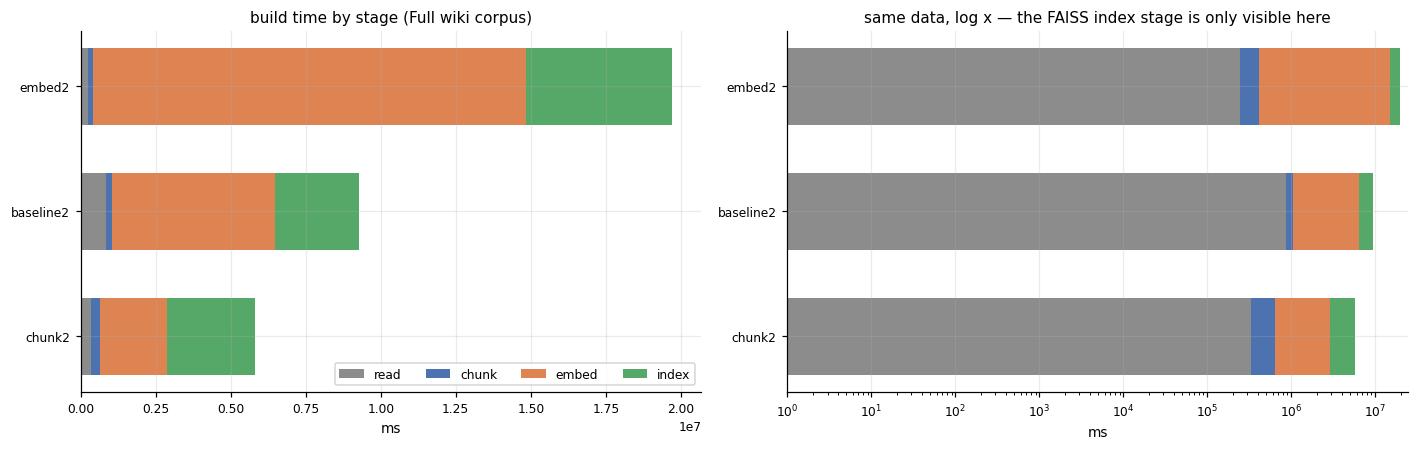

In [17]:
tbl = runs.set_index("arm")[[s + "_ms" for s in STAGES] + ["unaccounted_ms", "total_ms"]]
display(tbl.round(1))

order = list(runs.sort_values("total_ms")["arm"])
d = runs.set_index("arm").loc[order]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, logx in zip(axes, [False, True]):
    left = np.zeros(len(order))
    for s in STAGES:
        ax.barh(range(len(order)), d[s + "_ms"].values, left=left,
                color=STAGE_COLOR[s], label=s, height=0.62)
        left = left + d[s + "_ms"].values
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_xlabel("ms")
    if logx:
        ax.set_xscale("log")
        ax.set_xlim(left=1)
        ax.set_title("same data, log x — the FAISS index stage is only visible here")
    else:
        ax.set_title("build time by stage (Full wiki corpus)")
axes[0].legend(ncol=4, loc="lower right")
fig.tight_layout()
fig.savefig(FIGS / "build_time_by_stage.png", bbox_inches="tight")
plt.show()

,change,read_ms_x,chunk_ms_x,embed_ms_x,index_ms_x,total_ms_x
arm,,,,,,
baseline2,- (reference),1.0,1.0,1.0,1.0,1.0
embed2,"embedder.metric=dot, embedder.model=multi-qa-m...",0.284913,0.917594,2.649113,1.730974,2.116647
chunk2,chunker.type=sentence,0.388592,1.736945,0.411444,1.046603,0.626174


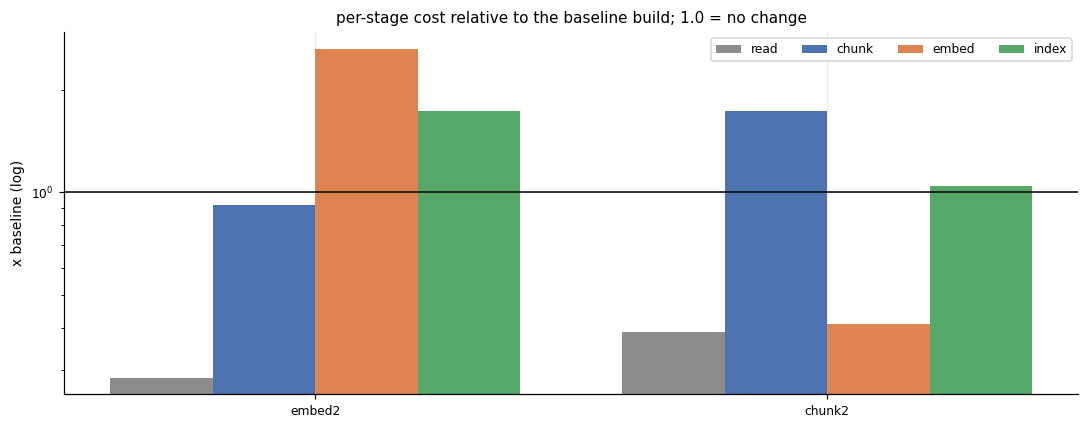

In [18]:
base = runs.set_index("job_id").loc[BASELINE_JOB]
cols = [s + "_ms" for s in STAGES] + ["total_ms"]

absolute = runs.set_index("arm")[cols]
ratio    = (absolute / base[cols]).add_suffix("_x")
comp     = absolute.join(ratio).round(2)
comp.insert(0, "change", runs.set_index("arm")["change_vs_baseline"])
display(comp[["change"] + [c for c in comp.columns if c.endswith("_x")]])

arms = [a for a in runs["arm"] if a != ARM[BASELINE_JOB]]
fig, ax = plt.subplots(figsize=(10, 4))
w, x = 0.2, np.arange(len(arms))
for i, s in enumerate(STAGES):
    vals = [ratio.loc[a, s + "_ms_x"] for a in arms]
    ax.bar(x + (i - 1.5) * w, vals, w, color=STAGE_COLOR[s], label=s)
ax.axhline(1, color="k", lw=1)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(arms, fontsize=8)
ax.set_ylabel("x baseline (log)")
ax.set_title("per-stage cost relative to the baseline build; 1.0 = no change")
ax.legend(ncol=4)
fig.tight_layout()
fig.savefig(FIGS / "stage_ratio_vs_baseline.png", bbox_inches="tight")
plt.show()

## Per-batch behaviour — is there a steady state?

The build processes `offline.file_chunk_size = 1000` articles per batch, four batches per
run. Whether batch 0 is slower than batches 1-3 tells you whether the run-level throughput
figure is a warm number or a cold one.

,baseline2,chunk2,embed2
batch_idx,,,
0,5092.0,1550.0,2125.0
1,5112.0,2184.0,1734.0
2,5238.0,2174.0,2451.0
3,5631.0,2513.0,2170.0
4,5512.0,2996.0,2254.0
...,...,...,...
5885,5550.0,3223.0,2112.0
5886,6033.0,4692.0,2840.0
5887,5684.0,3688.0,2097.0


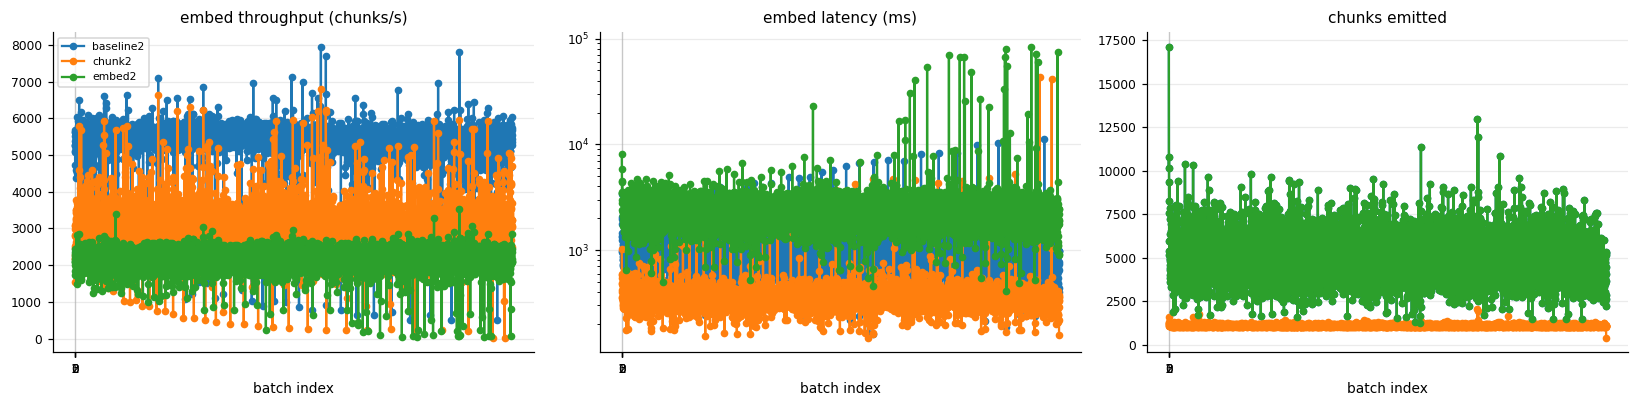

first-batch penalty (batch 0 embed chunks/s over the mean of batches 1-3):
  baseline2                     0.94x   (batch0 5,092  vs  rest 5,410)
  chunk2                        0.49x   (batch0 1,550  vs  rest 3,137)
  embed2                        0.98x   (batch0 2,125  vs  rest 2,167)


In [19]:
piv = batches.pivot_table(index="batch_idx", columns="job_id", values="embed_chunks_s")
piv.columns = [ARM[c] for c in piv.columns]
display(piv.round(0))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (col, lab) in zip(axes, [("embed_chunks_s", "embed throughput (chunks/s)"),
                                 ("embed_ms",       "embed latency (ms)"),
                                 ("n_chunks",       "chunks emitted")]):
    for job, g in batches.groupby("job_id"):
        g = g.sort_values("batch_idx")
        ax.plot(g["batch_idx"], g[col], marker="o", ms=4, label=ARM[job])
    ax.set_xlabel("batch index")
    ax.set_title(lab)
    ax.set_xticks([0, 1, 2, 3])
axes[1].set_yscale("log")
axes[0].legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGS / "per_batch_throughput.png", bbox_inches="tight")
plt.show()

print("first-batch penalty (batch 0 embed chunks/s over the mean of batches 1-3):")
for job, g in batches.groupby("job_id"):
    g = g.sort_values("batch_idx")
    b0, rest = g.iloc[0]["embed_chunks_s"], g.iloc[1:]["embed_chunks_s"].mean()
    print("  {:<28} {:5.2f}x   (batch0 {:,.0f}  vs  rest {:,.0f})".format(
        ARM[job], b0 / rest, b0, rest))

**Read.** Batch 0 runs within a few percent of the later batches in every arm, so the two
warmup rounds recorded in the trace did their job and the run-level rate is not dominated
by a cold first pass. What the batches do *not* give you is independent replication: they
share one process, one model load and one allocator state, so their spread is within-run
jitter, not run-to-run variance. Section 8 is the only place a genuine repeat exists.

Batch chunk counts vary by ~2x (7,543 to 17,126 for the baseline) purely because articles
differ in length — worth remembering when reading any single-batch number.

## Hardware traces — fixing the columns first

`monitor.sh` invokes:

```
dcgmi dmon -e 203,204,155,1001,1002,1009,1010 -c 1 \
  | awk 'NR>2 { pw+=$4; gu+=$2; mc+=$3; gr+=$5; sm+=$6; ptx+=$7; prx+=$8; n++ } ...'
```

`dcgmi dmon` prints each row as `GPU <id> <v1> <v2> ...`, so the entity label occupies
**two** awk fields, not one. Every value is therefore read one column early. Two
signatures in the data confirm it beyond doubt:

- `dcgmi_gpu_util_pct` is the constant **0.5** in every row of every file — that is `$2`,
  the mean of the GPU *entity IDs* {0, 1}, not a utilisation.
- `dcgmi_gr_active` sits at **64.0-212.8**, an impossible range for a 0-1 activity ratio
  and an entirely sensible one for H100 watts; meanwhile `dcgmi_power_w` maxes out at
  **24.5**, which is a percentage.

The corrected mapping, applied on load below:

| CSV header | actually contains |
|---|---|
| `dcgmi_gpu_util_pct` | mean GPU entity id (constant — drop) |
| `dcgmi_mem_copy_util_pct` | GPU utilisation % (field `203`) |
| `dcgmi_power_w` | memory-copy utilisation % (`204`) |
| `dcgmi_gr_active` | **power, W** (`155`) |
| `dcgmi_sm_active` | graphics-engine active ratio (`1001`) |
| `dcgmi_pcie_tx_bytes` | SM active ratio (`1002`) |
| `dcgmi_pcie_rx_bytes` | PCIe TX bytes (`1009`) |
| — | PCIe RX (`1010`) is dropped entirely: `$9` is never summed |

The fix in `monitor.sh` is `pw+=$5; gu+=$3; mc+=$4; gr+=$6; sm+=$7; ptx+=$8; prx+=$9`.

Worth flagging that this was *believed fixed*: the CSV header was corrected to seven
correctly-named columns, but the awk offsets underneath it were not, so the header now
asserts a mapping the parser does not produce. Post-header-fix CSVs look more trustworthy
than pre-fix ones and are exactly as wrong. Check the awk line, not the header, before
trusting any future run.

**Second issue, not fixable in post:** `nvidia-smi` is filtered to the job's own device via
`CUDA_VISIBLE_DEVICES`, but `dcgmi dmon` is not — it reports every GPU entity on the node
and the awk averages them. With two entities and one allocated GPU, every DCGM number here
is *(ours + neighbour) / 2*. `gpu_mem_used_mb` is per-GPU and trustworthy; DCGM power and
activity are node-averaged and must be labelled as such wherever they are quoted.

In [20]:
DCGM_FIX = {
    "dcgmi_gpu_util_pct":      "dcgm_entity_id_mean",
    "dcgmi_mem_copy_util_pct": "gpu_util_pct_dcgm",
    "dcgmi_power_w":           "mem_copy_util_pct",
    "dcgmi_gr_active":         "power_w",
    "dcgmi_sm_active":         "gr_active",
    "dcgmi_pcie_tx_bytes":     "sm_active",
    "dcgmi_pcie_rx_bytes":     "pcie_tx_bytes",
}


def load_hw(kind="offline"):
    frames = []
    for p in find("hardware_" + kind + "_*.csv"):
        job = re.search(r"_(\d+)\.csv$", p.name).group(1)
        d = pd.read_csv(p, parse_dates=["timestamp"]).rename(columns=DCGM_FIX)
        d["job_id"] = job
        d["gpu_mem_GB"] = d["gpu_mem_used_mb"] / 1000   # GB, not GiB - matches the figures already recorded elsewhere
        frames.append(d)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


hw = load_hw()
hw = hw[hw.job_id.isin(JOBS)].copy()

sanity = hw.groupby("job_id").agg(
    n_samples=("timestamp", "size"),
    median_interval_s=("timestamp", lambda s: s.diff().dt.total_seconds().median()),
    dcgm_entity_id_mean=("dcgm_entity_id_mean", "mean"),
    idle_power_W=("power_w", lambda s: s.iloc[:60].mean()),
    max_power_W=("power_w", "max"),
    max_gr_active=("gr_active", "max"),
    peak_gpu_mem_GB=("gpu_mem_GB", "max"),
)
sanity.index = [ARM[i] for i in sanity.index]
display(sanity.round(2))
print("Post-fix sanity check: idle power near 64 W and activity ratios inside [0, 1].")
print("The raw headers give neither, which is how the mislabelling was found.")

,n_samples,median_interval_s,dcgm_entity_id_mean,idle_power_W,max_power_W,max_gr_active,peak_gpu_mem_GB
baseline2,10976,1.0,0.5,64.71,134.99,0.13,6.95
chunk2,2299,3.0,0.5,64.36,253.52,0.46,4.83
embed2,3442,3.0,0.5,64.36,262.87,0.48,35.77


Post-fix sanity check: idle power near 64 W and activity ratios inside [0, 1].
The raw headers give neither, which is how the mislabelling was found.


## The stage-overlaid hardware timeline

For each run, one metric per panel on a shared time axis — GPU utilisation, then VRAM, then
power — and no twin axes, so no curve has to be matched to a left or right scale. The split
also keeps the scoping honest: util and VRAM are nvidia-smi columns that `monitor.sh` filters
to `$CUDA_VISIBLE_DEVICES`, so they describe **this job's own card**, while power is a DCGM
column averaged over **every card on the node** — the ~64 W floor is the neighbour, not this
job. Beneath them a ribbon shows exactly when `read`, `chunk`, `embed` and `index` were
running, batch by batch, on the same axis. Every hardware sample is drawn as a marker so the
sampling density is visible rather than hidden by line interpolation.

Two views per run — the whole job first, then the build window zoomed.

In [21]:
def stage_spans(job):
    # [(stage, t_start, t_end, batch_idx)] for every batch of a run.
    g = batches[batches.job_id == job].sort_values("batch_idx")
    return [(s, r[s + "_start"], r[s + "_end"], int(r["batch_idx"]))
            for _, r in g.iterrows() for s in STAGES]


def phase_spans(job):
    # Coarse process phases from the environment/warmup block.
    r = runs.set_index("job_id").loc[job]
    ph = [("import + model load", r.proc_start,     r.embedder_ready, "#B07AA1"),
          ("chunker build",       r.embedder_ready, r.chunker_ready,  "#4C72B0"),
          ("db import + init",    r.chunker_ready,  r.db_ready,       "#55A868")]
    if pd.notna(r.warmup_start):
        ph.append(("warmup", r.warmup_start, r.warmup_end, "#EDC948"))
    ph.append(("build", r.build_start, r.build_end, "#C44E52"))
    return ph


# One metric per panel, stacked on a shared time axis: no twin axes, so no
# reader has to work out which curve belongs to which side. Each draw_* returns
# (handles, labels) for a single figure-level legend.
UTIL_COLOR  = "#C44E52"
MEM_COLOR   = "#4C72B0"
POWER_COLOR = "#937860"


def draw_util(ax, d, t0, marker=True):
    # nvidia-smi, filtered by monitor.sh to $CUDA_VISIBLE_DEVICES
    x = (d["timestamp"] - t0).dt.total_seconds()
    ax.fill_between(x, 0, d["gpu_util_pct"], color=UTIL_COLOR, alpha=0.13, lw=0)
    ax.plot(x, d["gpu_util_pct"], color=UTIL_COLOR, lw=1.2,
            marker="o" if marker else None, ms=3,
            label="GPU util (%)")
    ax.set_ylabel("% utilisation")
    ax.set_ylim(-4, 104)
    return ax.get_legend_handles_labels()


def draw_mem(ax, d, t0, marker=True):
    # Also nvidia-smi, also job-scoped, but a capacity number rather than an
    # activity one - held allocation, not work done. Its own scale keeps that clear.
    x = (d["timestamp"] - t0).dt.total_seconds()
    ax.fill_between(x, 0, d["gpu_mem_GB"], color=MEM_COLOR, alpha=0.13, lw=0)
    ax.plot(x, d["gpu_mem_GB"], color=MEM_COLOR, lw=1.2,
            marker="s" if marker else None, ms=3,
            label="GPU mem (GB)")
    ax.set_ylabel("VRAM (GB)")
    ax.set_ylim(bottom=0)
    ax.margins(y=0.18)
    return ax.get_legend_handles_labels()


def draw_power(ax, d, t0, marker=True):
    # dcgmi is NOT filtered to the job's card, so this is the mean over every GPU
    # entity on the node - the ~64 W floor is the neighbour, not this job.
    x = (d["timestamp"] - t0).dt.total_seconds()
    ax.plot(x, d["power_w"], color=POWER_COLOR, lw=1.2,
            marker="^" if marker else None, ms=3,
            label="GPU power (W, node mean over all cards)")
    ax.set_ylabel("W")
    ax.margins(y=0.18)
    return ax.get_legend_handles_labels()


def draw_metric_stack(axes, d, t0, marker=True):
    # axes = (util, mem, power), top to bottom. Returns pooled legend entries.
    hs, ls_ = [], []
    for a, fn in zip(axes, (draw_util, draw_mem, draw_power)):
        h, l = fn(a, d, t0, marker=marker)
        hs += h; ls_ += l
    return hs, ls_


def draw_stage_ribbon(ax, job, t0, axis_span_s=None):
    # A stage shorter than ~1/250th of the axis is thinner than a pixel
    spans = stage_spans(job)
    thresh = (axis_span_s or 1.0) / 250.0
    for i, s in enumerate(STAGES):
        segs = [((st - t0).total_seconds(), max((en - st).total_seconds(), 1e-3))
                for stg, st, en, _ in spans if stg == s]
        ax.broken_barh(segs, (i - 0.38, 0.76), facecolors=STAGE_COLOR[s], edgecolor="none")
        tiny = [x0 + w / 2 for x0, w in segs if w < thresh]
        if tiny:
            ax.plot(tiny, [i] * len(tiny), marker="v", ms=5, lw=0,
                    color=STAGE_COLOR[s], clip_on=False)
    for _, r in batches[batches.job_id == job].sort_values("batch_idx").iterrows():
        xb = (r["read_start"] - t0).total_seconds()
        ax.axvline(xb, color="k", lw=0.5, alpha=0.35)
        ax.text(xb, -0.62, "b" + str(int(r.batch_idx)), fontsize=7, color="0.3",
                ha="left", va="bottom")
    ax.set_yticks(range(len(STAGES)))
    ax.set_yticklabels(STAGES)
    ax.set_ylim(3.6, -0.75)
    ax.grid(False)

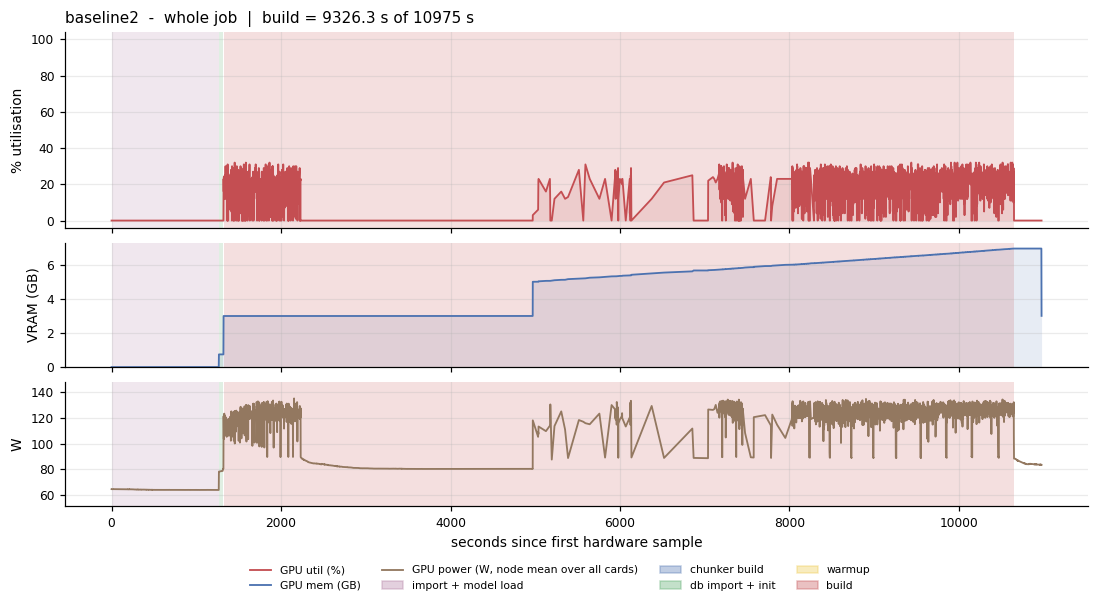

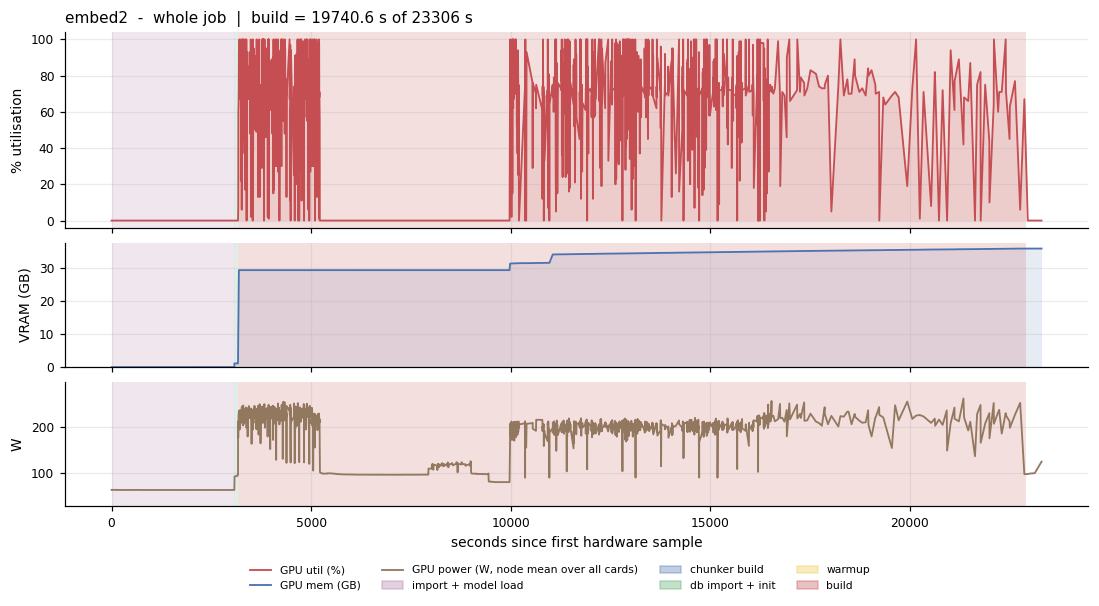

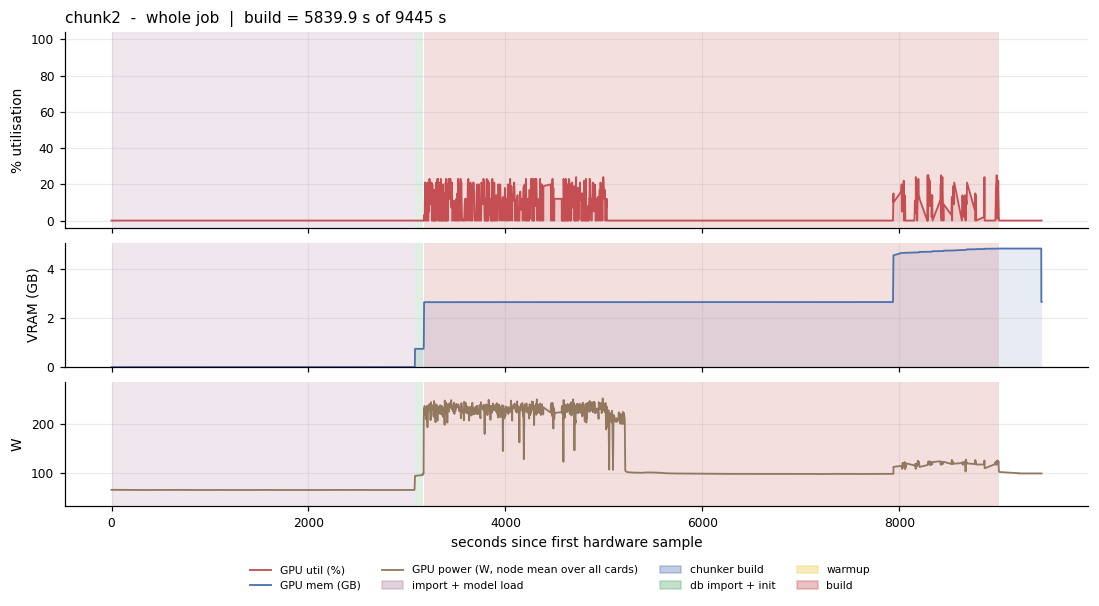

In [22]:
# --- View A: the whole job, coarse phases shaded --------------------------------
for job in JOBS:
    d = hw[hw.job_id == job]
    if d.empty:
        continue
    t0 = d["timestamp"].min()
    r  = runs.set_index("job_id").loc[job]

    # util / VRAM / power, one per panel, shared time axis.
    fig, axs = plt.subplots(
        3, 1, figsize=(12, 5.6), sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.4, 1.4], "hspace": 0.10})
    ax = axs[0]

    hs, ls_ = draw_metric_stack(axs, d, t0, marker=False)
    for lab, st, en, c in phase_spans(job):
        if pd.isna(st) or pd.isna(en):
            continue
        for a in axs:
            a.axvspan((st - t0).total_seconds(), (en - t0).total_seconds(),
                      color=c, alpha=0.18, lw=0)
    job_min = (d.timestamp.max() - t0).total_seconds()
    ax.set_title("{}  -  whole job  |  build = {:.1f} s of {:.0f} s".format(
        ARM[job], r.total_ms / 1000, job_min), loc="left")
    axs[-1].set_xlabel("seconds since first hardware sample")
    ph = [Patch(color=c, alpha=0.35, label=l) for l, s_, e_, c in phase_spans(job)]
    fig.legend(hs + ph, ls_ + [p.get_label() for p in ph], ncol=4, fontsize=7,
               loc="upper center", bbox_to_anchor=(0.5, 0.03), frameon=False)
    fig.savefig(FIGS / ("timeline_job_" + r.config + ".png"), bbox_inches="tight")
    plt.show()

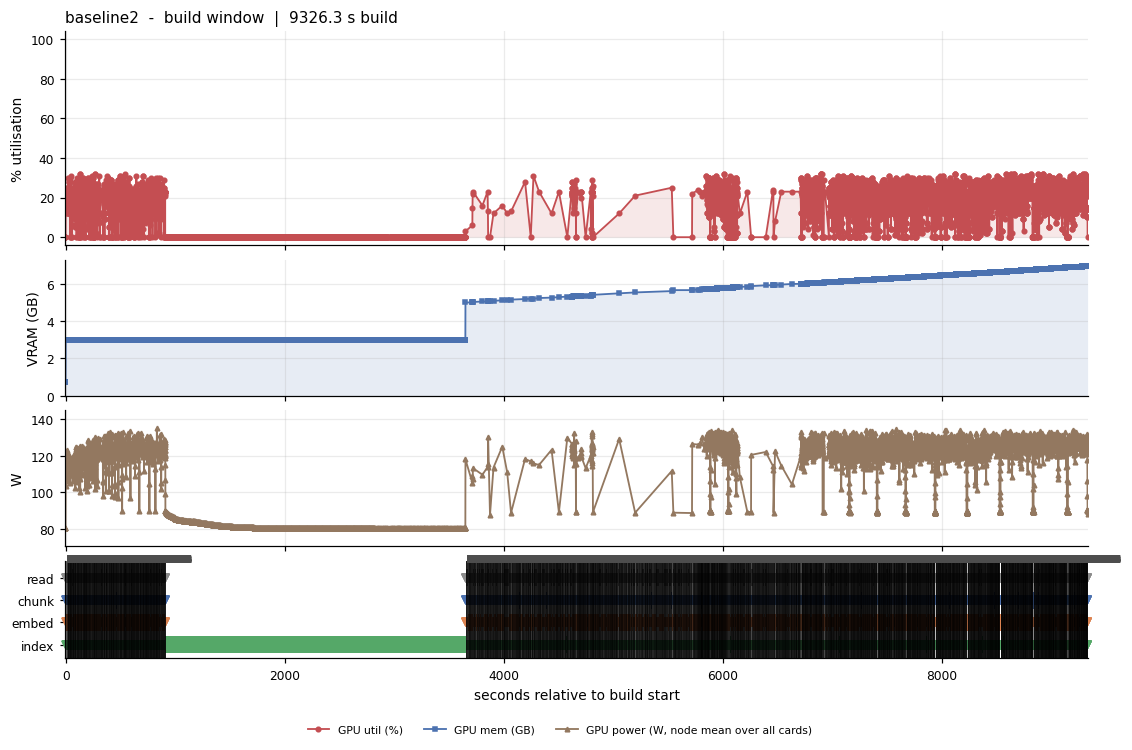

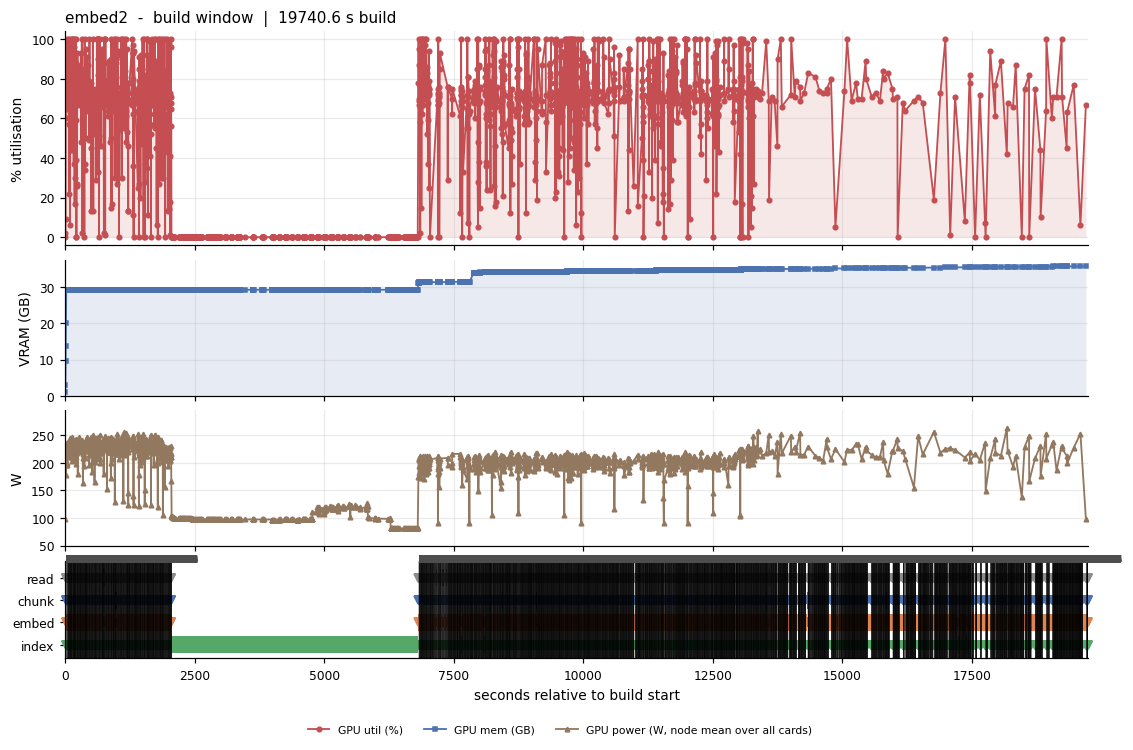

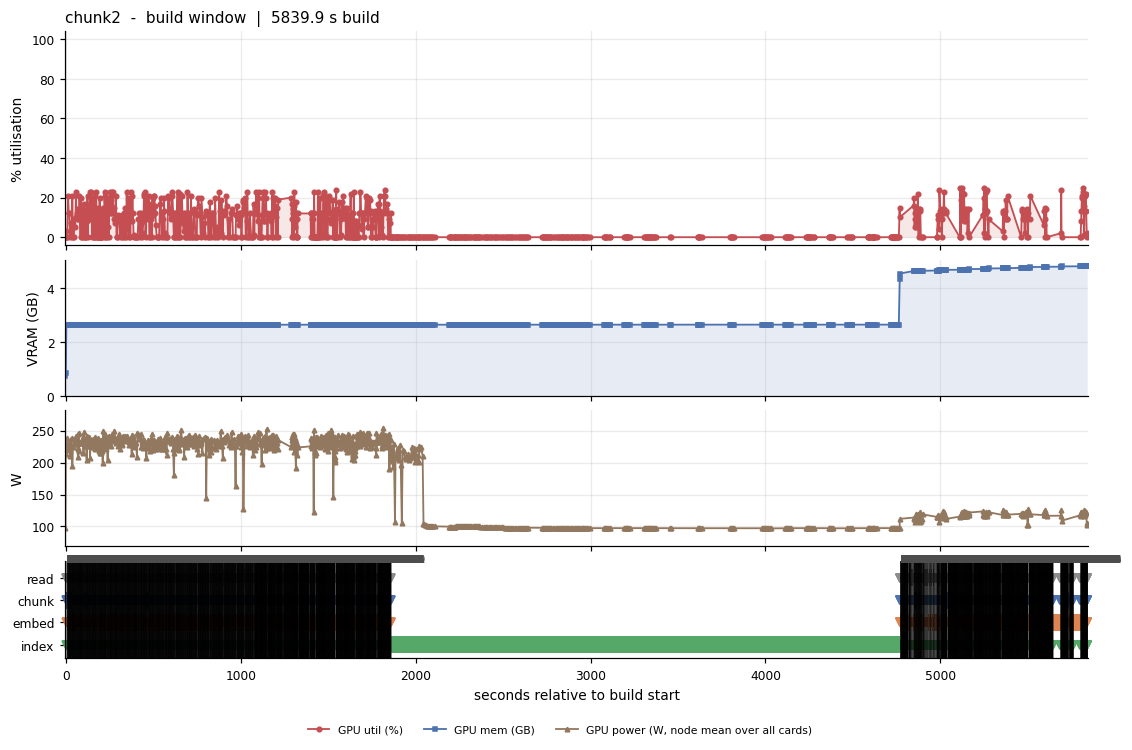

In [23]:
# --- View B: the build window, per-batch stage boundaries laid on top ------------
PAD_S = 6   # seconds of context either side of the build

for job in JOBS:
    d = hw[hw.job_id == job]
    r = runs.set_index("job_id").loc[job]
    if d.empty:
        continue
    lo = r.build_start - pd.Timedelta(seconds=PAD_S)
    hi = r.build_end   + pd.Timedelta(seconds=PAD_S)
    w  = d[(d.timestamp >= lo) & (d.timestamp <= hi)]
    t0 = r.build_start

    # util / VRAM / power one per panel, stage ribbon last, all on one time axis.
    # The ribbon carries the stage boundaries on its own - the curve panels stay
    # unshaded so the lines are read against a clean background.
    fig, (ax, axm, axp, axr) = plt.subplots(
        4, 1, figsize=(12, 7.4), sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.4, 1.4, 1.0], "hspace": 0.10})
    curves = (ax, axm, axp)

    hs, ls_ = draw_metric_stack(curves, w, t0)
    ax.set_title("{}  -  build window  |  {:.1f} s build".format(
        ARM[job], r.total_ms / 1000), loc="left")
    fig.legend(hs, ls_, ncol=3, fontsize=7, loc="upper center",
               bbox_to_anchor=(0.5, 0.04), frameon=False)

    axis_span = (hi - lo).total_seconds()
    draw_stage_ribbon(axr, job, t0, axis_span_s=axis_span)
    axr.set_xlabel("seconds relative to build start")
    axr.set_xlim((lo - t0).total_seconds(), (hi - t0).total_seconds())
    fig.savefig(FIGS / ("timeline_build_" + r.config + ".png"), bbox_inches="tight")
    plt.show()

## GPU behaviour

One scoping fact governs every number below. `monitor.sh` filters `nvidia-smi` to
`$CUDA_VISIBLE_DEVICES`, so `gpu_util_pct` and `gpu_mem_used_mb` describe **this job's own
card**. It does *not* filter `dcgmi` - the awk sums every row `dmon` prints and divides by the
count - so every `dcgm_*` column is a **mean over all cards on the node**. The next cell
recovers how many cards that was from `dcgm_entity_id_mean`, undilutes the DCGM ratios, and
checks the result against `gpu_util_pct`, the one column that was already job-scoped.

In [24]:
# --- Which GPU columns describe THIS job, and which describe the node ---------
# nvidia-smi is filtered to $CUDA_VISIBLE_DEVICES by monitor.sh, so `gpu_util_pct`
# and `gpu_mem_used_mb` are the job's own card. dcgmi is NOT filtered - its awk
# averages every row dmon prints - so every dcgm column is a mean over all the
# cards on the node. `dcgm_entity_id_mean` is the mean of the entity ids it
# averaged over, which recovers how many that was: mean of {0..N-1} = (N-1)/2.
DCGM_GPUS = int(round(2 * hw["dcgm_entity_id_mean"].mean() + 1))

DCGM_CEIL = {"gpu_util_pct_dcgm": 100.0, "mem_copy_util_pct": 100.0,
             "gr_active": 1.0, "sm_active": 1.0}
for c, ceil in DCGM_CEIL.items():
    hw[c + "_card"] = hw[c] * DCGM_GPUS
hw["pcie_tx_MBs"] = hw["pcie_tx_bytes"] * DCGM_GPUS / 1e6

over = {c: float((hw[c + "_card"] > ceil).mean() * 100) for c, ceil in DCGM_CEIL.items()}
print("dcgmi averaged over {} GPU(s); dcgm columns x{} to recover the active card."
      .format(DCGM_GPUS, DCGM_GPUS))
print("samples where the reconstruction exceeds its ceiling (other card was NOT idle):")
print("  " + ",  ".join("{}: {:.2f}%".format(k, v) for k, v in over.items()))
# Cross-check the reconstruction against the one column that is already job-scoped.
both = hw[(hw.gpu_util_pct > 0) & (hw.gpu_util_pct_dcgm > 0)]
if len(both):
    print("median gpu_util_pct / gpu_util_pct_dcgm on active samples: {:.2f}  (expect {})"
          .format(float((both.gpu_util_pct / both.gpu_util_pct_dcgm).median()), DCGM_GPUS))


def stage_label(d, job):
    # The stage each hardware sample fell inside; spans do not overlap.
    lab = pd.Series("outside build", index=d.index, dtype=object)
    for s, st, en, _ in stage_spans(job):
        lab[(d["timestamp"] >= st) & (d["timestamp"] <= en)] = s
    return lab


def build_window(job, pad_s=0):
    # Hardware rows inside a run's build, plus optional context either side.
    r = runs.set_index("job_id").loc[job]
    d = hw[hw.job_id == job]
    lo = r.build_start - pd.Timedelta(seconds=pad_s)
    hi = r.build_end   + pd.Timedelta(seconds=pad_s)
    return d[(d["timestamp"] >= lo) & (d["timestamp"] <= hi)], r


def n_note(n):
    # Every GPU figure carries its own sample count: at 1 Hz a 3.7 s build
    return "n={} hw sample{}".format(n, "" if n == 1 else "s")

gpu_tbl = []
for job in JOBS:
    d = hw[hw.job_id == job]
    if d.empty:
        continue
    r  = runs.set_index("job_id").loc[job]
    b  = d[(d["timestamp"] >= r.build_start) & (d["timestamp"] <= r.build_end)]
    em = d[stage_label(d, job) == "embed"]
    gpu_tbl.append({
        "arm": ARM[job], "build_s": round(r.total_ms / 1000, 1),
        "n_build": len(b), "n_embed": len(em),
        "util_mean_build": b["gpu_util_pct"].mean(),
        "util_p5_build":   b["gpu_util_pct"].quantile(0.05) if len(b) else np.nan,
        "util_p95_build":  b["gpu_util_pct"].quantile(0.95) if len(b) else np.nan,
        "util_max_build":  b["gpu_util_pct"].max() if len(b) else np.nan,
        "util_mean_embed": em["gpu_util_pct"].mean() if len(em) else np.nan,
        "sm_active_max_card": b["sm_active_card"].max() if len(b) else np.nan,
        "peak_mem_GB": d["gpu_mem_GB"].max(),
        "mem_headroom_GB": (d["gpu_mem_total_mb"].max() - d["gpu_mem_used_mb"].max()) / 1000,
    })
gpu_tbl = pd.DataFrame(gpu_tbl).set_index("arm")
display(gpu_tbl.round(2))

dcgmi averaged over 2 GPU(s); dcgm columns x2 to recover the active card.
samples where the reconstruction exceeds its ceiling (other card was NOT idle):
  gpu_util_pct_dcgm: 0.56%,  mem_copy_util_pct: 0.00%,  gr_active: 0.00%,  sm_active: 0.00%
median gpu_util_pct / gpu_util_pct_dcgm on active samples: 2.00  (expect 2)


,build_s,n_build,n_embed,util_mean_build,util_p5_build,util_p95_build,util_max_build,util_mean_embed,sm_active_max_card,peak_mem_GB,mem_headroom_GB
arm,,,,,,,,,,,
baseline2,9326.3,9196,6205,14.51,0.0,28.0,32.0,19.31,0.2,6.95,88.88
embed2,19740.6,2135,1667,55.36,0.0,100.0,100.0,69.18,0.8,35.77,60.06
chunk2,5839.9,953,511,6.39,0.0,21.0,25.0,9.05,0.8,4.83,91.00


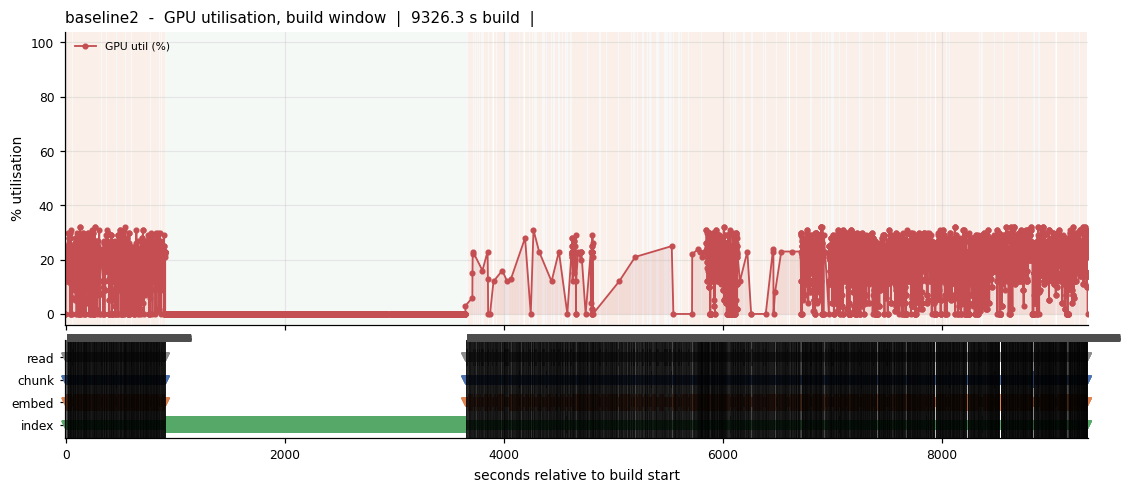

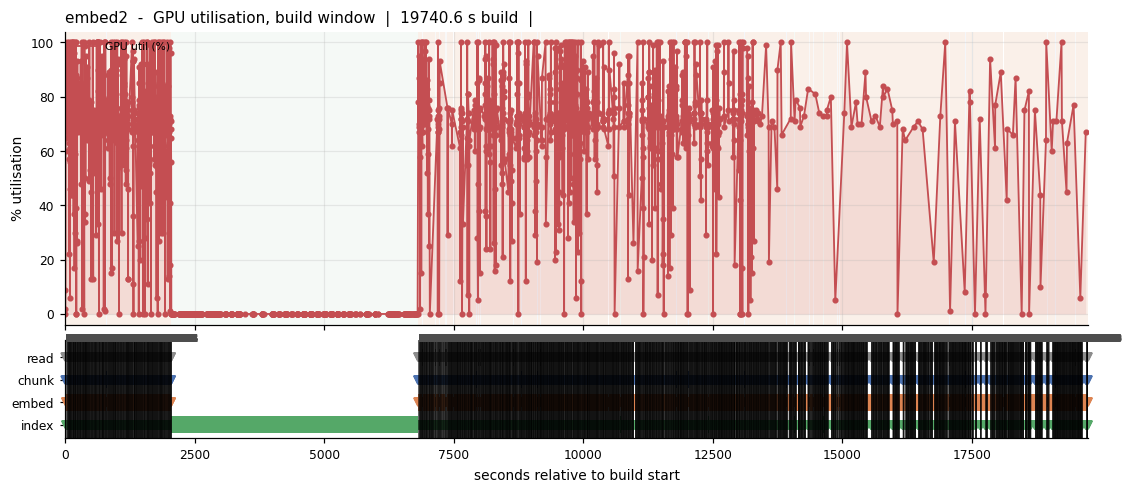

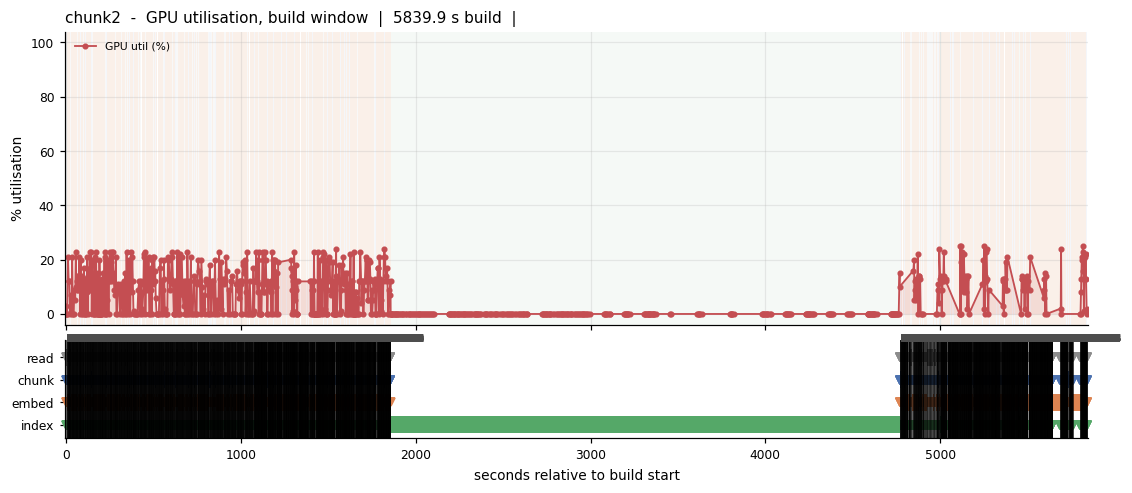

In [25]:
# View B: the build window, over the same per-batch stage ribbon section 6 uses.
GPU_PAD_S = 6

for job in JOBS:
    w, r = build_window(job, pad_s=GPU_PAD_S)
    if w.empty:
        print(ARM[job], "- no hardware samples in the build window, skipped")
        continue
    t0   = r.build_start
    n_in = len(build_window(job)[0])

    fig, (ax, axr) = plt.subplots(
        2, 1, figsize=(12, 4.8), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})

    draw_util(ax, w, t0)
    for s, st, en, _ in stage_spans(job):
        ax.axvspan((st - t0).total_seconds(), (en - t0).total_seconds(),
                   color=STAGE_COLOR[s], alpha=0.12 if s == "embed" else 0.06, lw=0)
    ax.set_title("{}  -  GPU utilisation, build window  |  {:.1f} s build  |"
                 .format(ARM[job], r.total_ms / 1000), loc="left")
    ax.legend(ncol=1, fontsize=7, loc="upper left", frameon=False)

    lo = (r.build_start - t0).total_seconds() - GPU_PAD_S
    hi = (r.build_end   - t0).total_seconds() + GPU_PAD_S
    draw_stage_ribbon(axr, job, t0, axis_span_s=hi - lo)
    axr.set_xlabel("seconds relative to build start")
    axr.set_xlim(lo, hi)
    fig.savefig(FIGS / ("gpu_util_build_" + r.config + ".png"), bbox_inches="tight")
    plt.show()

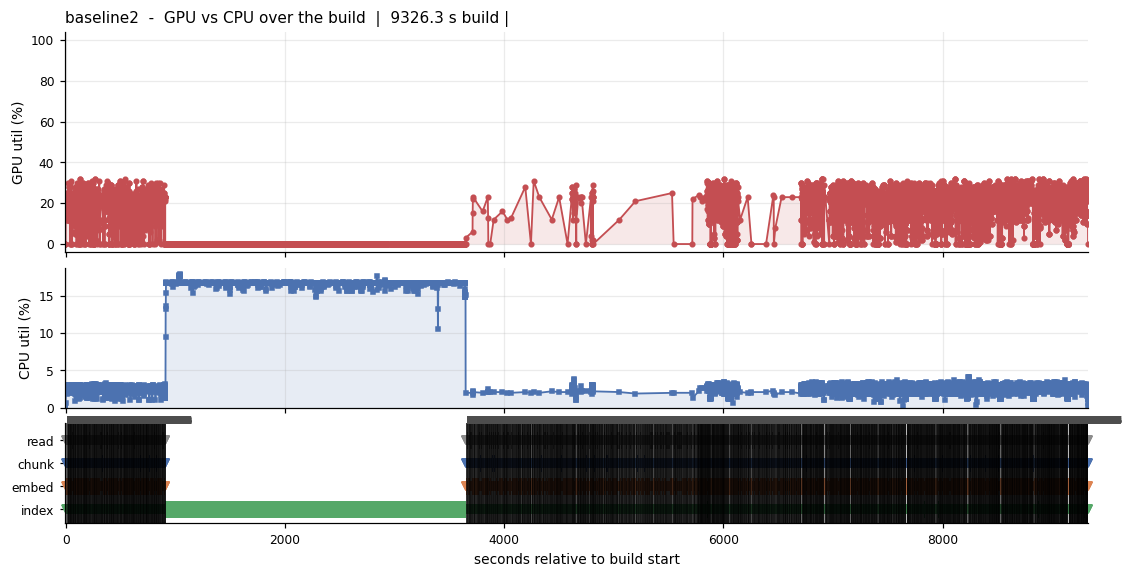

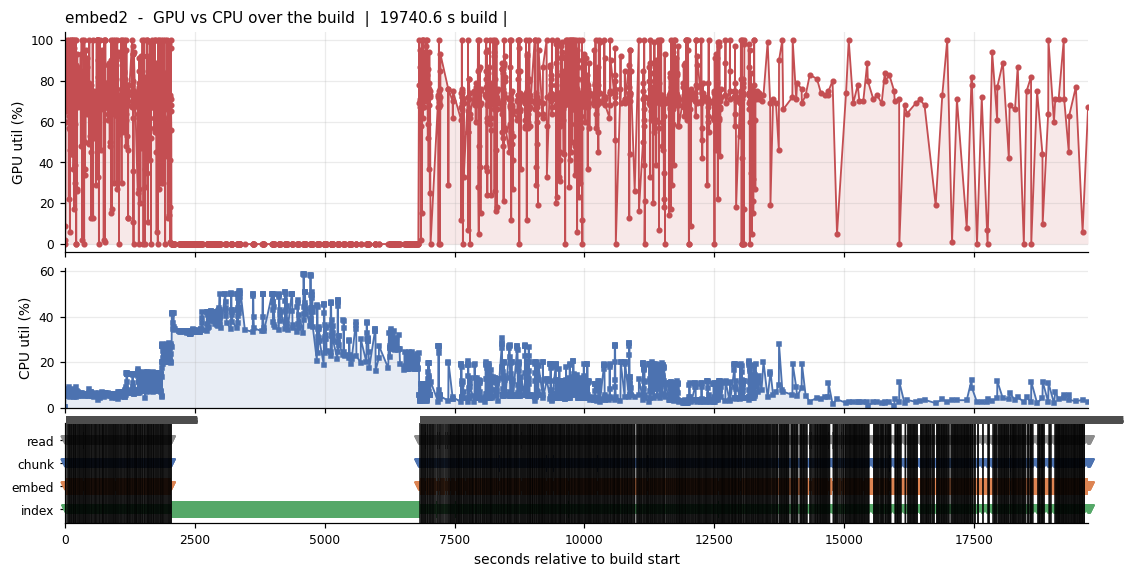

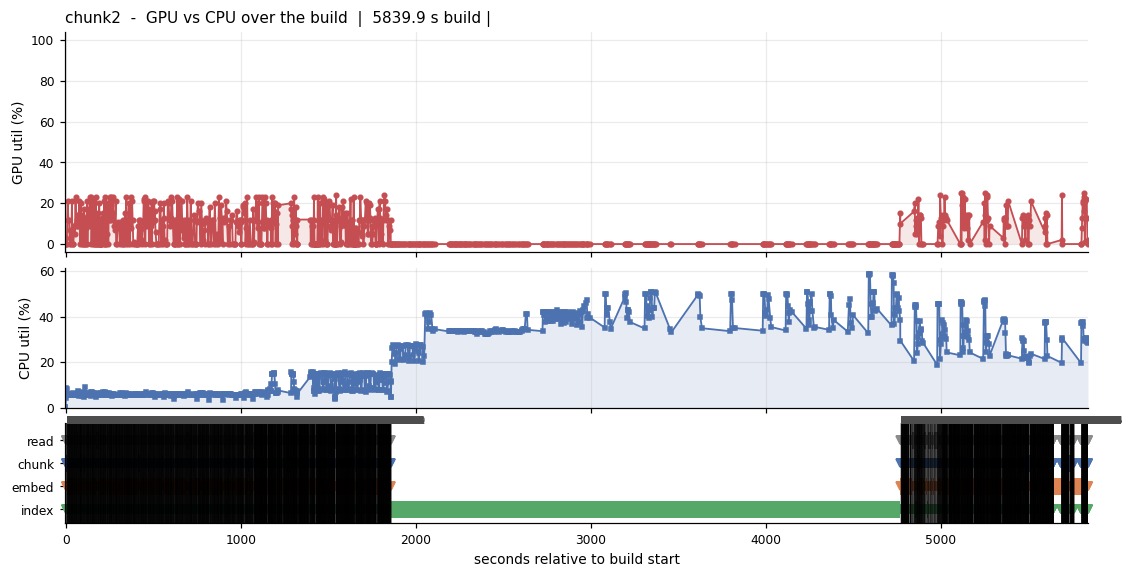

In [26]:
# --- 8.3  GPU against CPU: is the card fed, or is it waiting? -----------------
# cpu_util_pct comes from /proc/stat and is a NODE-WIDE percentage over every
# core. One fully-saturated core on a 64-core node reads ~1.6%, which is why it
# gets its own panel and its own scale rather than being squeezed onto the GPU's
# 0-100. Read the SHAPE against the GPU curve above it, not the height.
CPU_COLOR = "#4C72B0"


def draw_cpu(ax, d, t0, marker=True):
    x = (d["timestamp"] - t0).dt.total_seconds()
    ax.fill_between(x, 0, d["cpu_util_pct"], color=CPU_COLOR, alpha=0.13, lw=0)
    ax.plot(x, d["cpu_util_pct"], color=CPU_COLOR, lw=1.2,
            marker="s" if marker else None, ms=3,
            label="CPU util (% of node)")
    ax.set_ylabel("CPU util (%)")
    ax.set_ylim(bottom=0)
    ax.margins(y=0.18)
    return ax.get_legend_handles_labels()


for job in JOBS:
    w, r = build_window(job, pad_s=GPU_PAD_S)
    if len(w) < 2:
        print(ARM[job], "-", n_note(len(w)), "in the build window, too few to plot")
        continue
    t0 = r.build_start
    x  = (w["timestamp"] - t0).dt.total_seconds()

    # GPU on top, CPU beneath, stage ribbon last - one time axis for all three.
    fig, (ax, axc, axr) = plt.subplots(
        3, 1, figsize=(12, 5.8), sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.4, 1.0], "hspace": 0.10})

    draw_util(ax, w, t0)
    draw_cpu(axc, w, t0)

    ax.set_ylabel("GPU util (%)")

    ax.set_title("{}  -  GPU vs CPU over the build  |  {:.1f} s build |".format(
        ARM[job], r.total_ms / 1000), loc="left")

    lo, hi = float(x.min()), float(x.max())
    draw_stage_ribbon(axr, job, t0, axis_span_s=hi - lo)
    axr.set_xlabel("seconds relative to build start")
    axr.set_xlim(lo, hi)
    fig.savefig(FIGS / ("gpu_vs_cpu_" + r.config + ".png"), bbox_inches="tight")
    plt.show()

Rank: [ 1  2  3  4  5  6  7  8  9 10]
MRR contribution: [1.         0.5        0.33333333 0.25       0.2        0.16666667
 0.14285714 0.125      0.11111111 0.1       ]


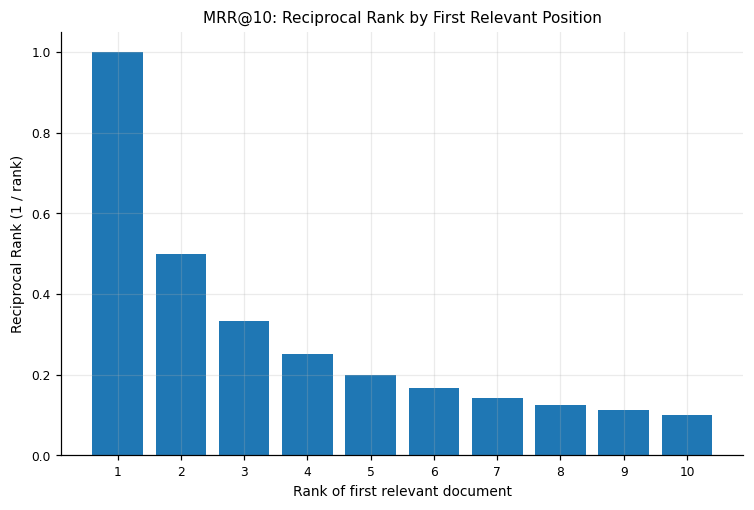

Sum of DCG for top 5 : 4.714447603066719

Sum of DCG for top 5 : 6.323465818787765



0.7455480488341595

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

top_k = 10
ranks = np.arange(1, top_k + 1)

# Reciprocal rank: 1 / rank
mrr_values = 1 / ranks

print("Rank:", ranks)
print("MRR contribution:", mrr_values)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(ranks, mrr_values)

plt.xlabel("Rank of first relevant document")
plt.ylabel("Reciprocal Rank (1 / rank)")
plt.title("MRR@10: Reciprocal Rank by First Relevant Position")
plt.xticks(ranks)

plt.show()


import math
rel_score = [1, 2, 0, 3, 3]
ideal_scores = sorted(rel_score, reverse=True)

def dcg_at_k(rel_scores, ideal_scores):
    k = 5
    sum_rel = 0
    sum_ideal = 0

    for i in range(k):
        item = rel_score[i]
        dcg = item / math.log(i + 2, 2)
    #    print(dcg)
        sum_rel += dcg
    print("Sum of DCG for top", k, ":", sum_rel)
    print()

    for i in range(k):
            item = ideal_scores[i]
            dcg = item / math.log(i + 2, 2)
    #        print(dcg)
            sum_ideal += dcg
    print("Sum of DCG for top", k, ":", sum_ideal)
    print()

    return sum_rel/sum_ideal

dcg_at_k(rel_score, ideal_scores)
